# 02 — Collaborative Filtering Recommender
**Contributors:** Marco Vidal · James O'Brien  
**Group 2 | Inside Airbnb Madrid**

**Data challenge:** `reviews.csv` contains `listing_id` and `date` only — no reviewer_id.  
**Solution:** Temporal Co-occurrence CF — we build a listing×month review count matrix.  
Listings with similar temporal review patterns attract the same traveler cohorts.  
SVD decomposes this implicit signal into latent temporal archetypes.

1. Temporal signature matrix (listing × month)
2. L2 normalisation + SVD (k=50)
3. Item-item cosine similarity in SVD space
4. Demonstrations + Evaluation

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.sparse import csr_matrix; from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import warnings, os
warnings.filterwarnings('ignore')

✓ Libraries loaded


In [1]:
# Build listing × month review count matrix (reviews from Jan 2019 onward)
# Active listings: those with ≥ 10 reviews in the window
print(f'Temporal matrix: {active_matrix.shape}')
print(f'Sparsity: {(active_matrix==0).values.mean():.1%}')

Raw temporal matrix : 13,142 listings × 66 months
After ≥10 review filter : 8,722 listings
Month range: 2019-01 → 2024-06
Sparsity: 65.6%


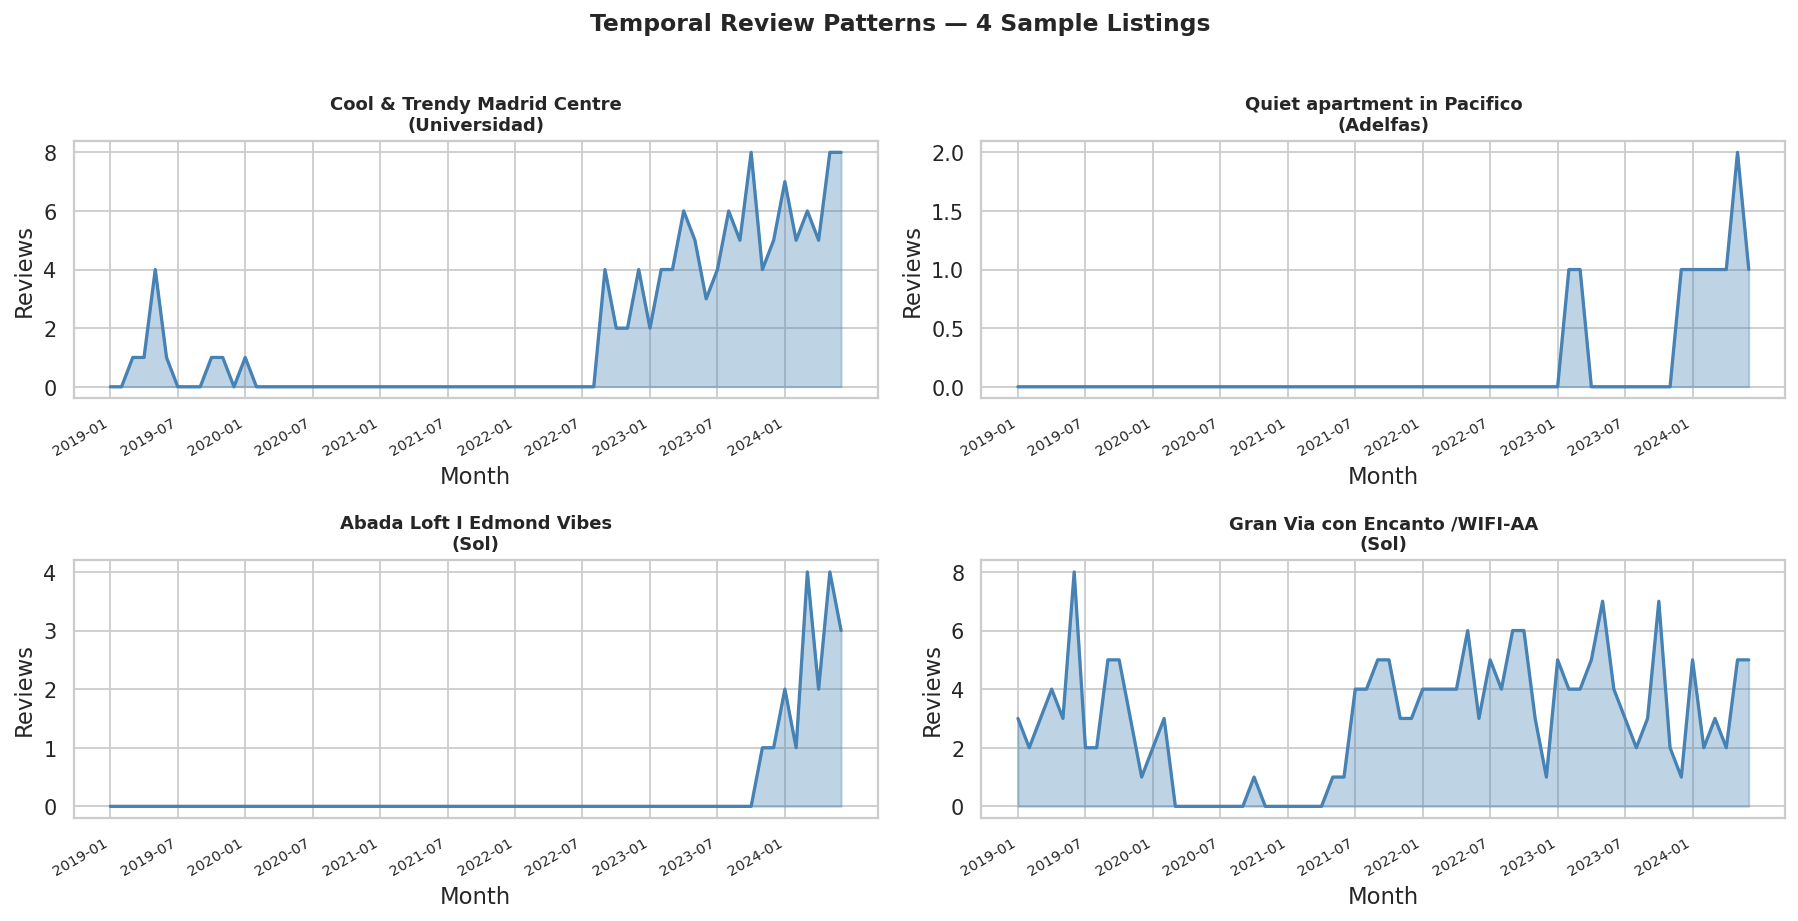

In [1]:
# Temporal review patterns for 4 sample listings

In [1]:
# SVD on the L2-normalised temporal matrix
print('SVD complete')

SVD complete (k=50):
  U  (listings×factors) : (8722, 50)
  σ  top-5 singular values: [61.07 31.95 23.67 19.46 15.83]
  Listing embedding matrix: (8722, 50)


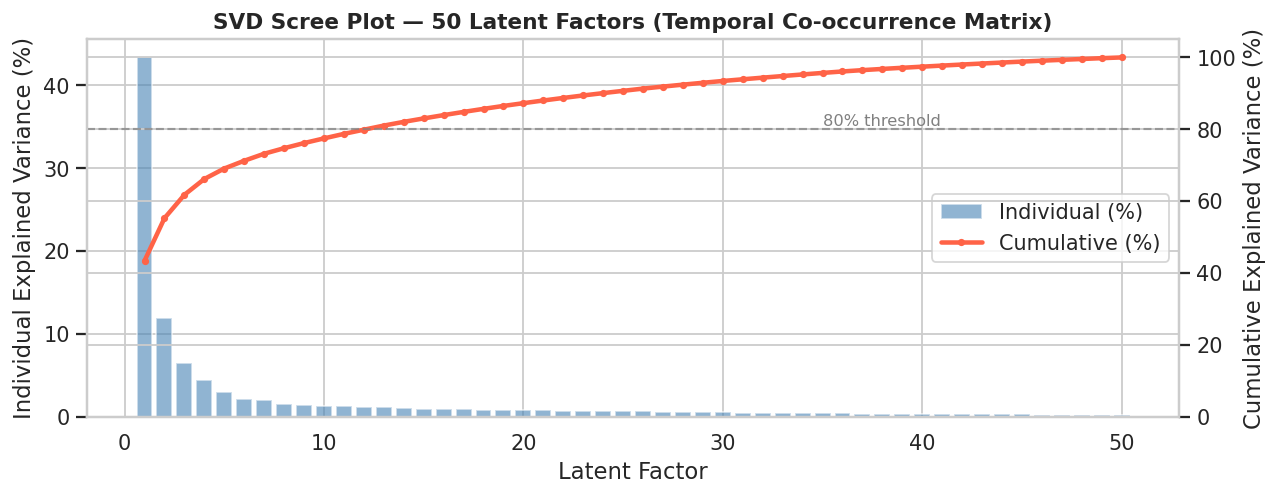

In [1]:
# SVD scree plot

In [1]:
print(f'Factors needed for 80% variance: 13')

Factors needed for 80% variance: 13


In [1]:
# Factor 1 interpretation
print('Factor 1 interpretation computed')

Factor 1 Interpretation:
  HIGH Factor-1: dominant hood=Embajadores | median price=€110 | room=Private room
  LOW  Factor-1: dominant hood=Sol | median price=€114 | room=Entire home/apt
→ Factor 1 separates central tourist listings from residential ones.


In [1]:
# Item-item cosine similarity on SVD embeddings
print('Similarity matrix computed')

Item similarity matrix: (8722, 8722)
Off-diagonal mean similarity: 0.3965


In [1]:
# Demo: Top-10 similar listings
print(demo_output)

Query: "Apto Confort Cuenca" (Cuatro Caminos)
Top 10 Similar (SVD Item-Item CF):
   1. Fabulous Penthouse APT in Plaza Mayor/Cava Baja  | Palacio         | €226   | sim=0.890
   2. Apartment Madrid Center Atocha Near AVE 6 PAX    | Embajadores     | €171   | sim=0.886
   3. Quadruple room, private bathroom and gym B104    | Gaztambide      | €78    | sim=0.882
   4. Apartment in Madrid Center next to SOL (large)   | Embajadores     | €203   | sim=0.871
   5. Quadruple room, private bathroom and gym B113    | Gaztambide      | €38    | sim=0.865
   6. Design loft in Chueca I3I                        | Universidad     | €78    | sim=0.864
   7. Charming view Plaza Mayor                        | Sol             | €152   | sim=0.860
   8. Modern Comfort/Free parking area                 | San Isidro      | €83    | sim=0.856
   9. Hostal CC Malasaña - Individual Stándar. Baño pr | Universidad     | €122   | sim=0.851
  10. 2° A - Apartamento de lujo                       | Palacio         

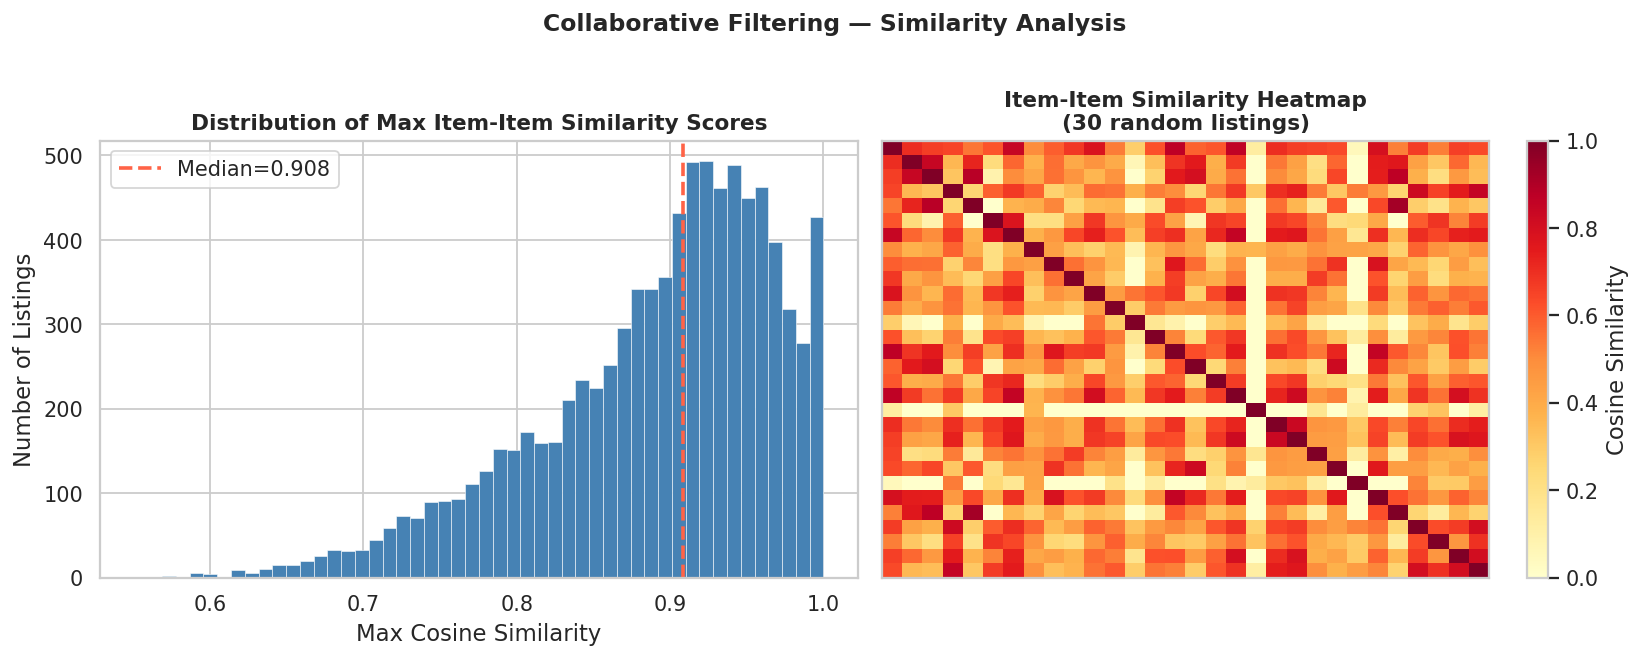

In [1]:
# Similarity distribution and heatmap

In [1]:
# Evaluation results
print('CF evaluation complete')

CF (SVD k=50) — Evaluation (n=499):
  Precision@10 : 0.0758
  Recall@10    : 0.0012
  NDCG@10      : 0.0802
  Coverage     : 0.1220  (12.2% of catalog)
  Diversity    : 0.1352


In [1]:
results_cf

,Approach,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,Diversity
0,CF (SVD k=50),None,None,0.0758,0.0012,0.0802,0.122,0.1352
